In [2]:
import pandas as pd 
import seaborn as sns 
import numpy as np

In [3]:
insurance_data = pd.read_csv("C:/Users/mayan/OneDrive/Desktop/Mayank(HP)/programs/Learning_AIML/Cleaned_data/insurance.csv")

In [4]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

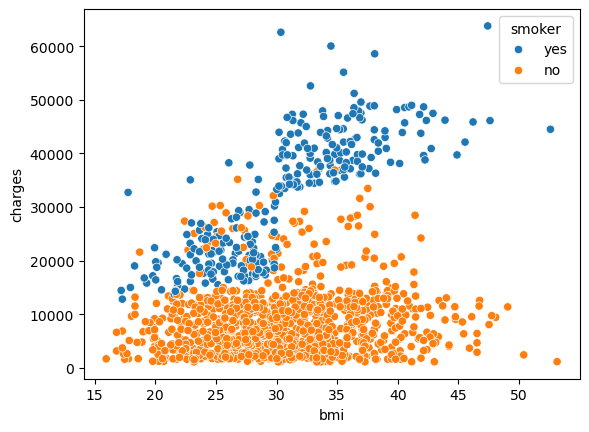

In [5]:
#Visualize Data 
sns.scatterplot(
    data = insurance_data,
    x = "bmi",
    y = "charges",
    hue="smoker", 
)



In [6]:
#Encoding of data , Because our algorithm only understands numerical values 
# X = Input features , Y = Output or dependent features 
X = insurance_data.drop(columns = ["charges", "region"])
y = insurance_data["charges"]

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

In [7]:
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [8]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [9]:
#Train Test Split, split the given dataset  into training and testing data 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)



In [10]:
#Train Model 
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train ,y_train)

LinearRegression()

In [11]:
#Predict values 
y_pred = model.predict(X_test)

In [12]:
#Priting Predicted values 
print (pd.Series(y_pred,index=y_test.index))

764      8554.817116
887      6973.587467
890     36798.604161
1293     9417.882823
259     26871.680311
            ...     
109     39220.995889
575     11695.634124
535      7253.598675
543     40950.539904
846     12625.966419
Length: 268, dtype: float64


In [13]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [14]:
#Evaluate our Model 
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print ("r-SquaredValue is : ",r2)

n = X_test.shape[0]
p = X_test.shape[1]
adjsuted_r2 = 1 - ((1- r2) * (n-1 ) / (n - p - 1))
print("adjsuted_r-SquaredValue is :",adjsuted_r2)

r-SquaredValue is :  0.7811302113434095
adjsuted_r-SquaredValue is : 0.7769533069797342


In [15]:
#Feature Engineering
#One hot Encoding

X = insurance_data.drop(columns = ["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns = ["region"],drop_first = True , dtype = int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

In [25]:
X.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,0,0,0,1
1,18,0,33.770,1,0,0,0,1,0
2,28,0,33.000,3,0,0,0,1,0
3,33,0,22.705,0,0,0,1,0,0
4,32,0,28.880,0,0,0,1,0,0


In [16]:
#TRAIN MODEL AGAIN
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train ,y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print ("r-SquaredValue is : ",r2)

r-SquaredValue is :  0.7835929767120724


In [17]:
#INTERACTION FEATURES 

X = insurance_data.drop(columns = ["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns = ["region"],drop_first = True , dtype = int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_Smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"]* X["smoker"]

In [18]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_Smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


In [20]:
#TRAIN MODEL AGAIN
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train ,y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print ("r-SquaredValue is : ",r2)

r-SquaredValue is :  0.865231697953168


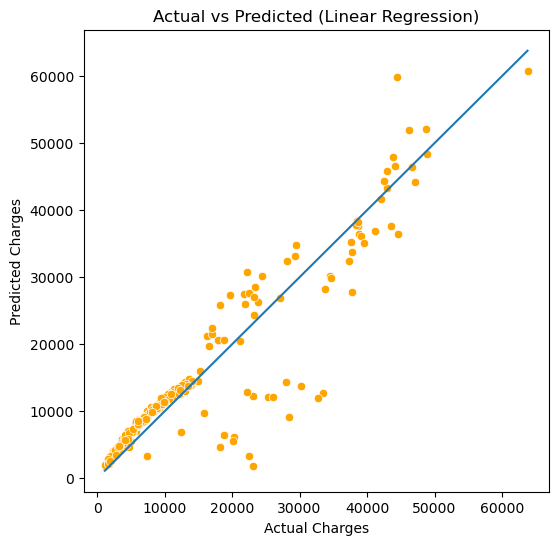

In [24]:
plt.figure(figsize=(6,6))

sns.scatterplot(x=y_test, y=y_pred,color = "orange")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()